# Лабораторная работа №1

## Задание

Необходимо познакомиться с фреймворком машинного обучения PyTorch и выполнить три задания:
1. Регрессия по теореме универсальной аппроксимации, ручное дифференцирование;
2. Бинарная классификация с помощью автодиффиренцирования PyTorch;
3. Обучить полносвязную нейронную сеть классификации 3 классов изображений из набора данных CIFAR100 по варианту из примера и затем повысить точность на тестовой выборке.

Для задания 3 нужно сформировать свою подвыборку CIFAR100 по варианту (см. ниже).

Лабораторные выполняются на платформе Google Colab - просто перейдите по ссылки в начале ноутбука. Также можно работать с ноубуками лабораторных локально.

Отчет должен содержать: титульный лист, задание с вариантом, скриншоты и краткие пояснения по каждому этапу лабораторной работы, итоговую таблицу с результатами для всех вариантов обучения (пример ниже).

## Варианты для Задания 3

Вы должны использовать следующие классы из CIFAR100:
1. Номер группы (1, 2, 3 и т.д.) + 7
2. Номер варианта + 30
3. ИУ5 (Номер варианта + 50); ГУИМЦ (90); Иностранцы (93)

## Задания для самостоятельной работы

1. Проанализируйте результаты обучения вашей модели. Что говорит о ней точность на обучающей и тестовой выборках? С какими классами модель справляется лучше и почему?
2. Проанализируйте результаты обучения. Возникает ли переобучение вашей модели? Что необходимо сделать, чтобы нивелировать это (не используя регуляризацию)?
3. Измените размер батча, но сохраните общее количество итераций. Проанализируйте результаты обучения с новыми гиперпараметрами. Что изменилось и почему?
4. Уменьшите скорость обучения и увеличьте общее количество итераций, чтобы повысить точность модели.
5. Измените вашу модель - поменяйте количество нейронов и слоев. Проанализируйте результаты обучения новой модели. Найдите лучшие гиперпараметры для этой модели.
6. Укажите, какие действия помогли повысить точность вашей модели и объясните почему.


## Комментарии к самостоятельной работе

- Изменение скорости обучения и размера батча делаем только после нахождения момента переобучения - эпохи где ошибка на тестовой выборке самая маленькая. Иначе улучшением шагов вы можете усилить переобучение (улучшаться при обучении, ухудшаться для теста);

- Увеличение размера батча при том же числе итераций должно хоть немного (в среднем) улучшить обучение. Потому что мы делаем то же количество, но более хороших шагов. Это может не сходиться с опытом по разным причинам, но из теории мы ожидаем какое-то улучшение;

- Во сколько раз меняете скорость обучения или размер батча - во столько же меняете количество эпох для сохранения итераций. На практике это условие не нужно, потому что при новом обучении меняют сразу много гиперпараметров. Но мы учимся, поэтому исследуем поведение каждого гиперпараметра отдельно: мы не можем сравнить 5 больших шагов и 7 маленьких, можем сравнить 5 больших и 5 маленьких;

- При изменении модели нужно искать гиперпараметры заново - это новая модель. Не нужно расписывать снова все шаги, просто сделайте это сами - найдите переобучение и поищите скорость и размер батча, которые будут лучше.

## Контрольные вопросы для защиты

1. Полносвязная нейронная сеть: объясните структуру, вычисления, назначение слоев и составляющих нейронов;
2. Укажите количество нейронов, связей и весов в полносвязной нейронной сети;
3. Опишите задачи регрессии и классификации. Какие функции потерь применяются в этих задачах?
4. Опишите структуру набора данных и назначение его частей;
5. Опишите алгоритм стохастического градиентного спуска. Укажите назначение гиперпараметров. В чем отличие пакетного и стохастического спуска?
6. Что такое эпоха, итерация, батч обучения. Как они взаимосвязаны?
7. Что такое обучение с учителем, без учителя, с подкреплением? Приведите примеры методов и задач для каждого вида обучения;
8. Нарисуйте схемы для всех трех нейронных сетей из лабораторной.

## Описание итоговой таблицы

|  Конфигурация нейросети   |  Гиперпараметры  |  Точность  |  Комментарий
|----------|----------|----------|----------|
|  FC(10), FC(3)   | lr = 0.003, batch_size = 128, epochs = 100  |  test = 70%, train = 98%  |  Базовый вариант
|  FC(10), FC(3)   | lr = 0.001, batch_size = 128, epochs = 300  |  test = 72%, train = 99%  |  Уменьшили скорость обучения в 3 раза, для компенсации увеличили количество эпох в столько же раз

# Теория

## Методы и функции PyTorch

(Документация: https://pytorch.org/docs/stable/index.html)

Библиотеки.

Стандартные:
* __np__ - библиотека NumPy для работы с многомерными массивами данных
* __pickle__ - библиотека Pickle для сериализации и десериализации структур данных ЯП Python
* __PIL__ - легковесная библиотека Pillow для работы с изображениями и вывода графических элементов напрямую в Jupyter Notebook
* __matplotlib__ - библиотека для построения графиков, по большей части повторяет API Matlab'a

Машинное обучение:
* __sklearn__ - библиотека, реализующая в основном методы классического машинного обучения и инструменты для работы с ними

Глубокое обучение:
* __torch__ - библиотека Pytorch для глубокого обучения нейронных сетей

__Принятые сокращения__:
* `torch.nn` — `nn`
* `torch.nn.functional` — `F`
* `torch.optim` — `optim`

---

__Методы__:
* **`torch.tensor()`** — **РЕКОМЕНДУЕМЫЙ** способ создания тензора из данных (список, массив NumPy). В отличие от `torch.Tensor()`, он наследует тип данных входных данных, но позволяет явно задать `dtype`. **Всегда явно указывайте `dtype=torch.float32`**, чтобы избежать ошибок совместимости с весами модели. Пример: `torch.tensor(data, dtype=torch.float32)`.

* **`torch.Tensor()`** — конструктор класса, создаёт тензор из многомерного массива. **⚠️ ВАЖНО:** По умолчанию создаёт тензор с типом `float32`. На практике рекомендуется использовать `torch.tensor()` с явным указанием `dtype`.

* **`t.detach()`** — отключает тензор от вычислительного графа, создавая новую копию без `requires_grad`. Используется для извлечения значений (например, для визуализации) или для ручного обновления весов.

* **`t.numpy()`** — преобразует тензор в массив NumPy. **⚠️ ВАЖНО:** Работает только для тензоров на **CPU**. Для тензоров на GPU сначала нужно вызвать `t.cpu()`.

* **`t.item()`** — возвращает число типа `float` или `int`, но **только если тензор содержит ровно один элемент** (скаляр). Для многомерных тензоров используйте `t.numpy()`.

* **`t.to(dtype)`** — приводит тензор к указанному типу. Пример: `t.to(torch.int64)`. **⚠️ ВАЖНО (исправление ошибки):** По умолчанию все вычисления в PyTorch ведутся в **`float32`**, а не `float64` (в отличие от NumPy). Для повышения точности можно использовать `float64`, но это редко требуется и замедляет вычисления. `float16` применяется для экономии памяти и ускорения на современных GPU (mixed precision).

* **`torch.ones()`, `torch.zeros()`, `torch.transpose()`, `torch.reshape()`** — API полностью аналогично NumPy.

* **`torch.rand()`** — создаёт тензор со случайными числами из равномерного распределения `[0, 1)`. Размерности перечисляются через запятую.

* **`torch.t()`** или `t.T` — транспонирование для двумерных тензоров. Аналог `numpy.transpose`. Для многомерных используйте `t.permute()`.

* **`torch.sum()`** — суммирование элементов вдоль указанной оси (`dim`). Если суммирование производится вдоль последней оси, можно указать `dim=-1`. Для сохранения размерности используйте `keepdim=True`.

* **`torch.maximum()`** — поэлементное сравнение двух тензоров, возвращает максимум. Используется для реализации ReLU.

* **`@` (оператор матричного умножения)** — **РЕКОМЕНДУЕМЫЙ** способ перемножения тензоров. Является современной альтернативой `torch.mm()` и `torch.matmul()`. Для матриц размерностей `(M, N)` и `(N, K)` результат будет `(M, K)`. В коде выглядит как `A @ B`.

* **`torch.mm()`** — устаревающий способ перемножения только двумерных матриц. В современном коде рекомендуется использовать оператор `@`.

* **`torch.exp()`** — поэлементная экспонента. Полный аналог `np.exp()`.

* **`torch.log()`** — поэлементный натуральный логарифм. Полный аналог `np.log()`.

* **`torch.flatten()`** — "выпрямляет" тензор. Если указан `start_dim`, преобразование начинается с этой оси. Пример: `torch.flatten(t, start_dim=1)` для тензора `(100, 3, 32, 32)` даст `(100, 3072)`.

* **`F.one_hot()`** — преобразует индексы классов в one-hot векторы. Пример: `F.one_hot(torch.tensor([0, 2]), num_classes=3)` вернёт `[[1, 0, 0], [0, 0, 1]]`.

* **`TensorDataset`** (`torch.utils.data.TensorDataset`) — упаковывает несколько тензоров в единый объект (например, изображения и метки). Удобен, когда данные целиком помещаются в оперативную память.

* **`DataLoader`** (`torch.utils.data.DataLoader`) — основной инструмент подачи данных. Разбивает `Dataset` на мини-батчи, перемешивает (`shuffle=True`), загружает в несколько потоков (`num_workers`). Ключевые параметры: `batch_size`, `shuffle`, `num_workers` (лучше ставить `2-4` для ускорения на больших данных).

* **`torch.save()`** — сохраняет параметры модели на диск. Первый аргумент: `model.state_dict()` (словарь весов), второй — путь к файлу (например, `'model.pth'`). Для загрузки используется `model.load_state_dict(torch.load('model.pth'))`.

## Создание моделей

Создание моделей осуществляется при помощи модуля `torch.nn`. В нём уже реализованы самые популярные блоки (слои) для нейронных сетей:
* `Linear` — полносвязный слой
* `Conv2d` — свёрточный слой
* `MaxPool2d` — пуллинг (субдискретизация)
* `BatchNorm2d` — нормализация по батчу
* `ReLU`, `Softmax`, `Tanh` — функции активации
* `Dropout` — слой-регуляризатор

В данной лабораторной работе используются только два слоя: `Linear` и `ReLU`.

---

**Задать модель можно двумя способами:**

**1. `nn.Sequential`** — подходит для простых последовательных моделей (конвейер). Входной тензор проходит через слои один за другим.

```python
model = nn.Sequential(
    nn.Linear(input_dims, hidden_dims),
    nn.ReLU(),
    nn.Linear(hidden_dims, num_classes)
)
```

**2. Наследование от `nn.Module`** — для сложных архитектур с разветвлениями, пропусками (skip-connections) или множественными выходами.

```python
class MLP(nn.Module):
    def __init__(self, input_dims, hidden_dims, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dims, hidden_dims)
        self.fc2 = nn.Linear(hidden_dims, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)          # или torch.relu(x)
        x = self.fc2(x)
        return x

model = MLP(input_dims, hidden_dims, num_classes)
```

**Важно:** в `nn.Module` **обязательно** нужно переопределить метод `forward()` — он описывает, как данные проходят через сеть.

**Гибкость:** допускается вкладывать `nn.Sequential` внутрь `nn.Module`, что позволяет комбинировать подходы и строить сложные архитектуры.
```

## Обучение моделей

Перед обучением необходимо выбрать **функцию потерь** (Loss Function) и **оптимизатор**.

**Функции потерь** (модуль `nn`):
* `nn.MSELoss` — среднеквадратическая ошибка: `(y_pred - y_true)²`. Используется для **регрессии**.
* `nn.BCEWithLogitsLoss` — бинарная перекрёстная энтропия. Используется для **бинарной классификации** (объединяет сигмоиду и BCE для численной стабильности).
* `nn.CrossEntropyLoss` — категориальная перекрёстная энтропия. Используется для **многоклассовой классификации** (объединяет Softmax и NLLLoss).

**Альтернатива:** можно реализовать функцию потерь вручную:

```python
inputs, y = batch
outputs = model(inputs)
loss = ((outputs - y) ** 2).sum()  # MSELoss вручную
```

**Оптимизаторы** (модуль `torch.optim`):
* `optim.SGD` — классический стохастический градиентный спуск.
* В конструктор передаются параметры модели (`model.parameters()`) и гиперпараметры, например `lr` (learning rate).

---

**Цикл обучения:**

1. **`model.train()`** — переводит модель в **режим обучения** (включает Dropout, обновляет BatchNorm). Вызывается перед каждой эпохой.

2. **`optimizer.zero_grad()`** — **обязательно** очищает накопленные градиенты перед новым шагом. Без этого градиенты будут суммироваться.

3. **`loss.backward()`** — вычисляет градиенты всех параметров с помощью обратного распространения ошибки (autograd).

4. **`optimizer.step()`** — обновляет веса модели, используя вычисленные градиенты.

**Эпоха и итерация:**
* **Эпоха** — один полный проход по всему набору данных.
* **Итерация** — один шаг оптимизации (обработка одного мини-батча).

**Оценка модели:**
* После обучения или во время валидации используется **`model.eval()`** — переключает модель в режим **оценки** (отключает Dropout, фиксирует параметры BatchNorm).
* В этом режиме вычисления **не требуют градиентов**, поэтому их отключают с помощью `with torch.no_grad():` для экономии памяти и ускорения.

```python
model.eval()
with torch.no_grad():
    outputs = model(inputs)
    loss = criterion(outputs, labels)
```

## Проверка качества моделей

Для перевода модели в режим оценки (без обучения) используется метод **`model.eval()`**. В этом режиме отключаются слои регуляризации (Dropout, BatchNorm фиксируется).

**Важно:** перед проверкой необходимо **отключить вычисление градиентов** с помощью `with torch.no_grad():` - это предотвращает построение вычислительного графа, экономит память и ускоряет код.

Для преобразования выходного тензора модели в массив NumPy используется связка:
```python
outputs = model(inputs).detach().numpy()      # если данные на CPU
outputs = model(inputs).cpu().detach().numpy() # если данные на GPU
```
* `.detach()` — отключает тензор от графа вычислений (предотвращает утечки памяти)
* `.cpu()` — переносит тензор с GPU на CPU (обязательно перед `.numpy()`)
* `.numpy()` — преобразует в массив NumPy

**Логиты vs вероятности:**
* Модель возвращает **логиты** — значения до применения Softmax (могут быть любыми числами).
* Для получения **вероятностей** нужно применить `F.softmax(outputs, dim=1)`. Однако на практике это **необязательно**, если нужно только определить класс:
  * `argmax` по логитам даёт тот же результат, что и по вероятностям, так как Softmax — **монотонно возрастающая** функция.
* Для метрик типа **Accuracy@5** (попал ли правильный класс в топ-5) используется `argsort`, который сортирует логиты по убыванию и берёт первые K индексов.

```python
# Получение класса
pred_class = outputs.argmax(axis=-1)

# Получение топ-5 классов
top5_classes = outputs.argsort(axis=-1)[:, -5:]  # последние 5 (по возрастанию)
```

**Метрики качества** (например, `classification_report` из `sklearn.metrics`) считаются на основе предсказанных и истинных меток классов.

## Импортирование необходимых библиотек

In [9]:
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pickle
import sklearn
from sklearn.metrics import classification_report
from sklearn.datasets import make_circles, make_moons
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

import sys
import datetime
f_y = datetime.datetime.now().year
markers = ['o', 's', '^', 'D', 'v']
marker = markers[(f_y) % len(markers)]
cmaps = ['RdBu', 'coolwarm', 'seismic', 'PiYG', 'PRGn']
cmap = cmaps[(f_y// 2) % len(cmaps)]

In [ ]:
# ========== ВЕРСИИ БИБЛИОТЕК ==========
print("=" * 50)
print("ВЕРСИИ БИБЛИОТЕК:")
print("=" * 50)

print(f"Python:          {sys.version.split()[0]}")
print(f"NumPy:           {np.__version__}")
print(f"Matplotlib:      {plt.matplotlib.__version__}")
print(f"Pillow:          {Image.__version__}")
print(f"Scikit-learn:    {sklearn.__version__}")
print(f"PyTorch:         {torch.__version__}")

print("=" * 50)

ВЕРСИИ БИБЛИОТЕК:
Python:          3.12.13
NumPy:           2.0.2
Matplotlib:      3.10.0
Pillow:          11.3.0
Scikit-learn:    1.6.1
PyTorch:         2.11.0+cpu


Актуально для среды выполнения Colab v2026.4 (сменить среду выполнения -> Версия среды выполнения)
- Python:          3.12.13
- NumPy:           2.0.2
- Matplotlib:      3.10.0
- Pillow:          11.3.0
- Scikit-learn:    1.6.1
- PyTorch:         2.11.0+cpu

# Часть 1. Задача регрессии по теореме универсальной аппроксимации, ручное дифференцирование

## Генерация выборки и инициализация параметров нейронной сети

Теорема универсальной аппроксимации: MLP с одним скрытым слоем может аппроксимировать любую непрерывную функцию.

В этом блоке создаём синтетические данные (сигмоида + шум) и инициализируем веса сети для последующего обучения.

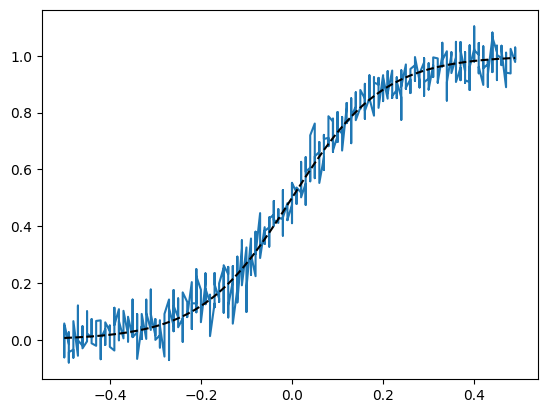

In [ ]:
# Генерация синтетических данных для задачи регрессии

# 500 точек в диапазоне [-0.5, 0.5]
X = (np.arange(100)/100 - 0.5).repeat(5)
# Целевая функция: сигмоида с крутым перепадом (активация, которую будем аппроксимировать)
y = 1/(1+np.exp(-10*X))

# Добавляем шум для имитации реальных данных (нормальное распределение, std=0.05)
yn = np.random.normal(scale=0.05, size=y.size)+y


# Визуализация: точки с шумом и идеальная функция (пунктирная линия)
plt.plot(X, yn)
plt.plot(X, y, linestyle='--', c='k')


# Преобразование numpy-массивов в тензоры PyTorch для работы с графом вычислений
# reshape(-1, 1) делает из одномерного массива вектор-столбец (500x1)
tensor_X = torch.Tensor(X.reshape(-1, 1))
tensor_y = torch.Tensor(yn.reshape(-1, 1))

In [ ]:
# Определение архитектуры MLP с одним скрытым слоем
# Входной слой: 1 признак (x), скрытый слой: 64 нейрона, выходной слой: 1 нейрон (y_pred)
HIDDEN_SIZE = 64


# Инициализация весов первого слоя (входной -> скрытый)

# Размер: (1, 64) - от 1 признака к 64 нейронам
weights_1 = (torch.rand(1, HIDDEN_SIZE)-.5)/10
# bias_1 - смещение для каждого нейрона скрытого слоя
bias_1 = torch.zeros(HIDDEN_SIZE)


# Инициализация весов второго слоя (скрытый -> выходной)

# Размер: (64, 1) - от 64 нейронов к 1 выходу
weights_2 = (torch.rand(HIDDEN_SIZE, 1)-.5)/10
# bias_2 - смещение на выходе
bias_2 = torch.zeros(1)

## Обучение нейронной сети задачи регрессии

Алгоритм обратного распространения ошибки (Backpropagation)

Шаг 0. Инициализация параметров
- Инициализировать веса и смещения случайными значениями
- Задать гиперпараметры: скорость обучения (lr), количество эпох, размер батча
- Подготовить обучающую выборку: входные данные X и целевые значения y

---

Шаг 1. Прямой проход (Forward Pass)
Для каждого обучающего примера вычислить выход сети:

1.1. Вычислить значения скрытого слоя:
- h_raw = X @ W₁ + b₁
- h_activated = f(h_raw)

1.2. Вычислить выход сети:
- y_pred = h_activated @ W₂ + b₂

---

Шаг 2. Вычисление функции потерь (Loss Calculation)
Рассчитать ошибку между предсказанным и истинным значением:
- L = (y_pred - y_true)²   # для регрессии (MSE)
- L = -y_true·log(y_pred)  # для классификации (Cross-Entropy)

---

Шаг 3. Обратный проход (Backward Pass)
Вычислить градиенты функции потерь по всем параметрам сети (цепное правило):

3.1. Вычислить производную ошибки по выходу сети:
- dL/dy_pred = 2 * (y_pred - y_true)   # для MSE
- dL/dy_pred = y_pred - y_true         # для Cross-Entropy с Softmax

3.2. Вычислить градиенты для второго (выходного) слоя:
- dW₂ = (h_activated)ᵀ @ (dL/dy_pred)   # градиент по весам W₂
- db₂ = sum(dL/dy_pred)                 # градиент по смещению b₂

3.3. Вычислить производную по скрытому слою:
- dL/dh = (dL/dy_pred) @ W₂ᵀ            # градиент по выходу скрытого слоя
- dL/dh_raw = dL/dh ⊙ f'(h_raw)         # умножение на производную активации

3.4. Вычислить градиенты для первого (входного) слоя:
- dW₁ = Xᵀ @ (dL/dh_raw)               # градиент по весам W₁
- db₁ = sum(dL/dh_raw)                  # градиент по смещению b₁

---

Шаг 4. Обновление параметров (Gradient Descent Step)
Изменить веса в направлении антиградиента:
- W₁ = W₁ - lr * dW₁
- b₁ = b₁ - lr * db₁
- W₂ = W₂ - lr * dW₂
- b₂ = b₂ - lr * db₂

---

Шаг 5. Проверка условий остановки

Повторять шаги 1-4 до достижения одного из критериев:
- Достигнуто максимальное количество эпох
- Значение функции потерь ниже заданного порога
- Градиенты стали близки к нулю
- Ошибка на валидационной выборке перестала уменьшаться (early stopping)

Финальная ошибка: 0.0026


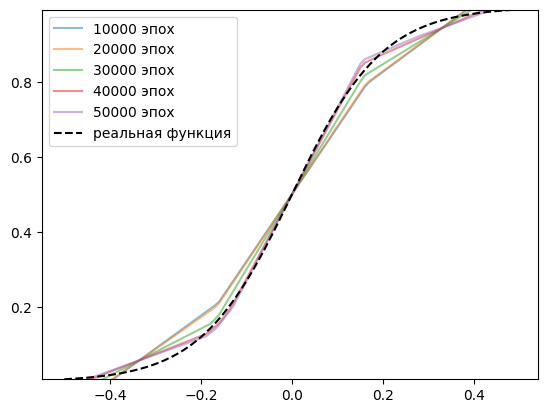

In [ ]:
# Определяем функцию активации (ReLU)
relu = lambda x: torch.maximum(x, torch.tensor(0.0))

# Прямой проход: вычисление выходного сигнала сети
def forward(x):
    # '@' - оператор матричного умножения (matmul). Эквивалентные записи: torch.mm(A, B) <=> A @ B
    hidden = relu(x @ weights_1 + bias_1)  # скрытый слой
    output = hidden @ weights_2 + bias_2  # выходной слой
    return output

# Функция потерь: среднеквадратичная ошибка (MSE)
def loss(y_pred, y_true):
    return ((y_pred - y_true)**2).mean()

# Ручной обратный проход (для демонстрации работы градиентов)
# Здесь показан analytical gradient, который autograd вычисляет автоматически
def backward(X, y_true, y_pred):
    # dL/dy_pred: производная MSE по выходу = [ (y_pred - y_true)^2 ]'
    dL = 2 * (y_pred - y_true)

    # Прямые значения до активации
    hidden_raw = X @ weights_1 + bias_1   # (500, 1) @ (1, 64) = (500, 64)
    hidden_activated = relu(hidden_raw)   # применяем активационную функцию

    # Градиенты для второго слоя (выходной)
    dW2 = hidden_activated.t() @ dL       # (64, 500) @ (500, 1) = (64, 1)
    db2 = dL.sum(axis=0)

    # Градиенты для первого слоя (скрытый)
    dHidden = dL @ weights_2.t()          # (500, 1) @ (1, 64) = (500, 64)
    dHidden[hidden_raw <= 0] = 0          # производная ReLU

    dW1 = X.t() @ dHidden                 # (1, 500) @ (500, 64) = (1, 64)
    db1 = dHidden.sum(axis=0)

    return dW1, db1, dW2, db2

# Шаг градиентного спуска (обновление параметров)
def sgd_step(params, grads, lr=0.0005):
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = grads
    return W1 - lr*dW1, b1 - lr*db1, W2 - lr*dW2, b2 - lr*db2

# 50 тысяч итераций градиентного спуска = 50 тысяч эпох
for epoch in range(50000):
    # Получить предсказание
    y_pred = forward(tensor_X)
    # Рассчитать значение функции потерь
    current_loss = loss(y_pred, tensor_y)
    # Рассчитать знчение градиентов
    grads = backward(tensor_X, tensor_y, y_pred)
    # Обновить значения W и bias
    weights_1, bias_1, weights_2, bias_2 = sgd_step(
        [weights_1, bias_1, weights_2, bias_2], grads, 1e-4
    )

    # Визуализация прогресса
    if (epoch + 1) % 10000 == 0:
        plt.plot(X, y_pred.detach().numpy(), label=f'{epoch+1} эпох', alpha=0.5)

plt.plot(X, y, linestyle='--', c='k', label='реальная функция')
plt.legend()
plt.ylim(y.min(), y.max())
print(f'Финальная ошибка: {current_loss.item():.4f}')

# Часть 2. Бинарная классификация с помощью автодиффиренцирования PyTorch

## Генерация выборки и инициализация параметров нейронной сети

XOR (исключающее ИЛИ) нельзя решить однослойным перцептроном, потому что классы 0 и 1 расположены по диагоналям квадрата и линейно неразделимы — нельзя провести одну прямую, которая разделила бы точки (0,0) и (1,1) от (0,1) и (1,0): это доказали Минский и Пейперт в 1969 году, что привело к "зиме ИИ" на 20 лет, и проблема решается только добавлением хотя бы одного скрытого слоя с нелинейной активацией (например, ReLU), который преобразует данные в новое линейно разделимое пространство, где выходной слой уже может провести разделяющую прямую.

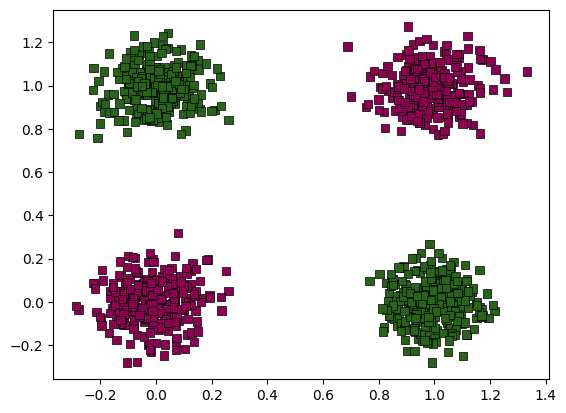

In [2]:
# Генерация данных для задачи XOR (исключающее ИЛИ)
X = np.random.randint(2, size=(1000, 2))  # 1000 точек с координатами 0 или 1
# Целевая функция: XOR (1 если значения x1 x2 разные, 0 если одинаковые)
y = (X[:, 0] + X[:, 1]) % 2

# Добавляем нормальный шум
X = X + np.random.normal(0, scale=0.1, size=X.shape)

# Визуализация: точки двух классов (0 и 1) на плоскости
# Классы расположены по диагоналям — линейно неразделимы
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, marker=marker, edgecolors='k', linewidth=0.5)

In [3]:
# Преобразование в тензоры PyTorch для работы с графом вычислений
tensor_X = torch.Tensor(X.reshape(-1, 2))  # (1000, 2) - два входных признака
tensor_y = torch.Tensor(y.reshape(-1, 1))  # (1000, 1) - один выход (0 или 1)

# Архитектура MLP: входной слой (2 нейрона) - скрытый слой (16) - выходной (1)
HIDDEN_SIZE = 16


# Инициализация весов первого слоя (входной - скрытый)

# Размер: (2, 16) — от 2 признаков к 16 нейронам скрытого слоя
# detach() — отключаем от предыдущего графа, requires_grad — включаем градиенты
weights_1 = ((torch.rand(2, HIDDEN_SIZE) - .5) / 10).detach().requires_grad_(True)

# Смещения для скрытого слоя (16 нейронов)
bias_1 = torch.zeros(HIDDEN_SIZE, requires_grad=True)


# Инициализация весов второго слоя (скрытый - выходной)

# Размер: (16, 1) — от 16 нейронов к 1 выходу
weights_2 = ((torch.rand(HIDDEN_SIZE, 1) - .5) / 10).detach().requires_grad_(True)

# Смещение для выходного слоя (1 нейрон)
bias_2 = torch.zeros(1, requires_grad=True)

## Обучение нейронной сети задачи классификации

In [4]:
# Активационная функция
# Определяем сигмоиду (можно использовать torch.sigmoid вместо самописной)
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

# Прямой проход: вычисление выхода сети
def forward(x):
    # Используем @ вместо torch.mm()
    hidden = x @ weights_1 + bias_1              # (1000, 2) @ (2, 16) = (1000, 16)
    hidden_nonlin = sigmoid(hidden)
    output = hidden_nonlin @ weights_2 + bias_2  # (1000, 16) @ (16, 1) = (1000, 1)
    return sigmoid(output)

# Функция потерь: бинарная кросс-энтропия (LogLoss)
def loss(y_true, y_pred):
    # Добавляем eps для избегания log(0)
    eps = 1e-8
    y_pred_clipped = torch.clamp(y_pred, eps, 1 - eps)
    # Используем sum(), а не mean() — при ручном обновлении весов (п.4) градиенты должны быть "полного размера"
    return - (y_true * torch.log(y_pred_clipped) + (1 - y_true) * torch.log(1 - y_pred_clipped)).sum()

# Гиперпараметры
lr = 1e-3
iters = 10000

# Список параметров для удобного обновления
params = [weights_1, bias_1, weights_2, bias_2]
losses = []

for i in range(iters):
    # 1. Прямой проход: вычисление предсказания
    y_pred = forward(tensor_X)

    # 2. Вычисление функции потерь
    lossval = loss(tensor_y, y_pred)

    # 3. Обратный проход: autograd вычисляет градиенты
    lossval.backward()  # в weights_1.grad, bias_1.grad и т.д. лежат производные

    # 4. Обновление весов вручную (демонстрация градиентного спуска)
    for w in params:
        with torch.no_grad():  # отключаем отслеживание градиентов при обновлении
            w -= w.grad * lr   # шаг градиентного спуска
        w.grad.zero_()         # обнуляем градиенты для следующей итерации

    # Сохранение истории для визуализации
    losses.append(lossval.item())

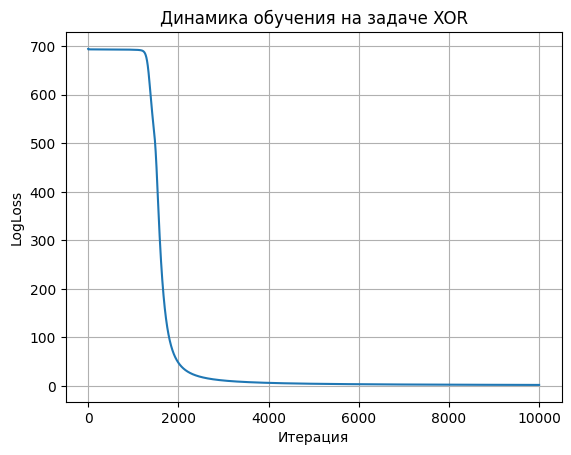

In [5]:
# Визуализация сходимости
plt.plot(losses)
plt.xlabel('Итерация')
plt.ylabel('LogLoss')
plt.title('Динамика обучения на задаче XOR')
plt.grid(True)
plt.show()

## Проверка результатов обучения

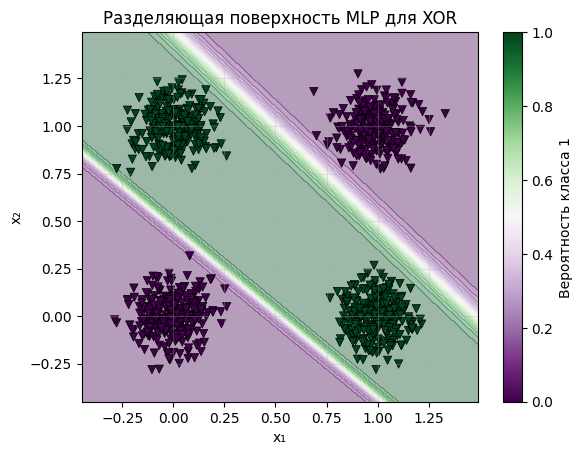

Точность на обучающей выборке: 100.00%


In [10]:
step = 0.01
# Создаем сетку - будем предсказывать значение для каждой точки поверхности с шагом step
X_diff = X.max() - X.min()
X_left = X.min() - 0.1 * X_diff
X_right = X.max() + 0.1 * X_diff
grid = np.arange(X_left, X_right, step)
grid_width = grid.size

surface = []
for x1 in grid:
    for x2 in grid:
        surface.append((x1, x2))
surface = np.array(surface)

# Получаем предсказания для всех точек сетки
with torch.no_grad():
    Z = forward(torch.Tensor(surface)).detach().numpy()

# Меняем форму
Z = Z.reshape(grid_width, grid_width)
xx = surface[:, 0].reshape(grid_width, grid_width)
yy = surface[:, 1].reshape(grid_width, grid_width)

# Рисуем разделяющую поверхность
plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap, levels=20)

# Рисуем обучающую выборку (используем y_pred из последней итерации)
with torch.no_grad():
    y_pred_final = forward(tensor_X).detach().numpy()
plt.scatter(X[:, 0], X[:, 1], c=y_pred_final > 0.5, marker=marker, cmap=cmap, edgecolors='k', linewidth=0.5)

# Задаём границы
plt.xlim(X_left, X_right)
plt.ylim(X_left, X_right)
plt.title('Разделяющая поверхность MLP для XOR')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.colorbar(label='Вероятность класса 1')
plt.grid(True, alpha=0.3)
plt.show()

# Дополнительно: проверка точности
with torch.no_grad():
    y_pred_final = forward(tensor_X)
    y_pred_binary = (y_pred_final > 0.5).float()
    accuracy = (y_pred_binary == tensor_y).float().mean().item()
    print(f"Точность на обучающей выборке: {accuracy*100:.2f}%")

# Часть 3. Классификация изображений CIFAR100

CIFAR-100 содержит 60 000 цветных изображений 32x32 пикселя.

50 000 — обучение, 10 000 — тест, разделённых на 100 классов.

## Загрузка и распаковка набора данных CIFAR100

In [2]:
# Использовать ли зеркало 'Kaggle' для загрузки
DOWNLOAD_FROM_KAGGLE = True
DATASET_PATH = 'cifar-100-python/train'

if DOWNLOAD_FROM_KAGGLE:
  import os
  import kagglehub

  # Download latest version
  path = kagglehub.dataset_download("fedesoriano/cifar100")

  print("Path to dataset files:", path)

  # Посмотрим, что там внутри
  print("Файлы в папке:", os.listdir(path))

  # Если там папка cifar-100-python
  if "cifar-100-python" in os.listdir(path):
      data_path = os.path.join(path, "cifar-100-python")
  else:
      data_path = path

  # Загружаем данные напрямую
  with open(os.path.join(data_path, 'train'), 'rb') as f:
      data_train = pickle.load(f, encoding='latin1')

  with open(os.path.join(data_path, 'test'), 'rb') as f:
      data_test = pickle.load(f, encoding='latin1')

  print("Train keys:", data_train.keys())
  print("Test keys:", data_test.keys())

  DATASET_PATH = path # "/root/.cache/kagglehub/datasets/fedesoriano/cifar100/versions/1"

else:
  !wget https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
  !tar -xvzf cifar-100-python.tar.gz

Using Colab cache for faster access to the 'cifar100' dataset.
Path to dataset files: /kaggle/input/cifar100
Файлы в папке: ['meta', 'file.txt', 'test', 'train']
Train keys: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])
Test keys: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])


## Чтение тренировочной и тестовой выборки

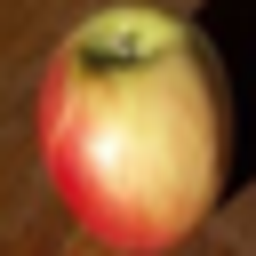

In [5]:
# В CIFAR-100 классы нумеруются от 0 до 99
# Здесь указать ваши классы по варианту!!!
CLASSES = [0, 55, 58]


# Загружаем обучающую и тестовую выборки
with open(os.path.join(DATASET_PATH, 'train'), 'rb') as f:
    data_train = pickle.load(f, encoding='latin1')

# Извлекаем метки классов (fine_labels — 100 классов, coarse_labels — 20 суперклассов)
train_y = np.array(data_train['fine_labels'])

# Сначала фильтруем по меткам - оставляем только изображения, относящиеся к заданным классам (работаем с плоским массивом)
mask = np.isin(train_y, CLASSES)
train_y_filtered = train_y[mask].copy()
train_X_flat = data_train['data'][mask].copy()       # (N, 3072) — экономим память

# Теперь преобразуем в формат изображений (только для отфильтрованных данных)
train_X = train_X_flat.reshape(-1, 3, 32, 32)        # (N, 3, 32, 32) — NCHW
# train_X = np.transpose(train_X, [0, 2, 3, 1])        # (N, 32, 32, 3) — NHWC для визуализации

# Перекодируем метки в 0, 1, 2
train_y = np.unique(train_y_filtered, return_inverse=1)[1]

del data_train, train_y_filtered, train_X_flat


with open(os.path.join(DATASET_PATH, 'test'), 'rb') as f:
    data_test = pickle.load(f, encoding='latin1')

# Аналогичные преобразования для тестовой выборки
test_y = np.array(data_test['fine_labels'])
mask = np.isin(test_y, CLASSES)

test_y_filtered = test_y[mask].copy()
test_X_flat = data_test['data'][mask].copy()

test_X = test_X_flat.reshape(-1, 3, 32, 32)
# test_X = np.transpose(test_X, [0, 2, 3, 1])

test_y = np.unique(test_y_filtered, return_inverse=1)[1]

del data_test, test_y_filtered, test_X_flat

# Для отображения изображения временно меняем порядок осей NCHW → NHWC
Image.fromarray(np.transpose(train_X[50], [1, 2, 0])).resize((256, 256))

## Создание Pytorch DataLoader'a

In [6]:
# Размер батча
batch_size = 128


# Создаём словарь для хранения загрузчиков данных (DataLoader)
# DataLoader — это итератор, который подаёт данные батчами во время обучения
dataloader = {}

# Обрабатываем обучающую и тестовую выборки в одном цикле
for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):

    # Преобразуем numpy-массивы в тензоры PyTorch # явно указываем тип
    tensor_x = torch.tensor(X, dtype=torch.float32)

    # Преобразуем метки в one-hot encoding (формально, необязательно - CrossEntropy может делать автоматически)
    # Например: [0, 1, 2] → [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
    # https://docs.pytorch.org/docs/2.12/generated/torch.nn.CrossEntropyLoss.html
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                         num_classes=len(CLASSES))/1.0    # /1.0 оставляет тип float # можно .float()

    # Создаём объект TensorDataset — связывает тензоры X и y
    dataset = TensorDataset(tensor_x, tensor_y)

    # Создаём DataLoader — он будет подавать данные батчами
    # shuffle=True — перемешивает данные перед каждой эпохой (важно для обучения!)
    dataloader[part] = DataLoader(dataset, batch_size=batch_size, shuffle=True)

dataloader

{'train': <torch.utils.data.dataloader.DataLoader at 0x7d6c883bc800>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7d6c8302bb30>}

## Создание Pytorch модели многослойного перцептрона с одним скрытым слоем

In [7]:
class Normalize(nn.Module):
    """
    Слой нормализации изображений перед подачей в нейросеть.
    Приводит пиксели к стандартному нормальному распределению (среднее=0, std=1).
    """
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        # Сохраняем среднее и std как тензоры (будут использоваться в forward)
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

    def forward(self, input):
        # 1. Нормализуем значения пикселей из диапазона [0, 255] в [0, 1]
        x = input / 255.0

        # 2. Центрируем данные: вычитаем среднее (теперь среднее = 0)
        x = x - self.mean

        # 3. Масштабируем: делим на стандартное отклонение (теперь std = 1)
        x = x / self.std

        return x


# https://blog.jovian.ai/image-classification-of-cifar100-dataset-using-pytorch-8b7145242df1
class Cifar100_MLP(nn.Module):
    """
    Многослойный перцептрон (MLP) для классификации изображений CIFAR-100.
    Архитектура: входной слой (3072 нейрона) - скрытый слой (hidden_size) - выходной слой (classes)
    """
    def __init__(self, hidden_size=32, classes=100, mean=None, std=None):
        super(Cifar100_MLP, self).__init__()

        # Если mean и std не переданы — используем стандартные для всего CIFAR-100
        if mean is None:
            mean = [0.5074, 0.4867, 0.4411]
        if std is None:
            std = [0.2011, 0.1987, 0.2025]

        # Слой нормализации
        self.norm = Normalize(mean, std)

        self.flatten = nn.Flatten()

        # Последовательность слоёв:
        # 1. Полносвязный слой: 3072 входа - hidden_size нейронов
        # 2. ReLU - нелинейная активация (пропускает положительные значения, обнуляет отрицательные)
        # 3. Полносвязный слой: hidden_size - classes (выходные логиты)
        self.seq = nn.Sequential(
            nn.Linear(32*32*3, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, classes),
        )

    def forward(self, input):
        # Прямой проход:
        # 1. Нормализация входных изображений
        x = self.norm(input)
        # 2. Сплющиваем изображение в одномерный вектор для полносвязного слоя
        # Было: (N, 3, 32, 32) → стало: (N, 3*32*32) = (N, 3072)
        x = self.flatten(x)
        # 3. Проход через полносвязные слои
        return self.seq(x)

In [9]:
# Так как мы используем только 3 класса из 100, статистики всего датасета не подходят
# Нужно пересчитать среднее и стандартное отклонение для нашей подвыборки

# Вычисляем среднее по каждому каналу (усредняем по батчу, высоте и ширине)
mean = train_X_nchw.mean(axis=(0, 2, 3)).astype(np.float32) / 255.0  # (3,) — среднее для R, G, B
std = train_X_nchw.std(axis=(0, 2, 3)).astype(np.float32) / 255.0    # (3,) — std для R, G, B

print(f"Пересчитанные mean: {mean}")
print(f"Пересчитанные std: {std}")

Пересчитанные mean: [0.5539192  0.53335816 0.51861966 0.50513667 0.4937175  0.48544562
 0.4805168  0.4764092  0.47055137 0.46554446 0.46142688 0.4566336
 0.45286307 0.45022246 0.4474182  0.445027   0.44555366 0.44759154
 0.44936347 0.45233765 0.45564002 0.4592028  0.46252984 0.46694472
 0.474024   0.48147774 0.4878851  0.49627104 0.5078619  0.51987475
 0.53196496 0.5472009 ]
Пересчитанные std: [0.2945149  0.2898838  0.28795567 0.28575724 0.28299636 0.27985126
 0.27594092 0.27299824 0.27044103 0.26790747 0.26625314 0.26454282
 0.26371893 0.26382926 0.26377624 0.26311663 0.26303872 0.26370347
 0.26501346 0.26663008 0.26718783 0.26733428 0.26891705 0.27065378
 0.27302673 0.2761215  0.27931878 0.28211024 0.28505722 0.2875949
 0.28994545 0.29335317]


In [10]:
# Количество нейронов в скрытом слое
HIDDEN_SIZE = 10

# Создаём экземпляр модели для классификации на заданные классы, используя рассчитанные mean/std
model = Cifar100_MLP(hidden_size=HIDDEN_SIZE, classes=len(CLASSES),
                     mean=mean, std=std)
model

Cifar100_MLP(
  (norm): Normalize()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (seq): Sequential(
    (0): Linear(in_features=3072, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=3, bias=True)
  )
)

## Выбор функции потерь и оптимизатора градиентного спуска

In [11]:
# Функция ошибки / CrossEntropy для много-класс
criterion = nn.CrossEntropyLoss()

# Оптимизатор
optimizer = optim.SGD(model.parameters(), lr=0.005)

## Обучение модели по эпохам

In [12]:
EPOCHS = 250

# количество батчей в обучающей выборке
steps_per_epoch = len(dataloader['train'])
# количество батчей в тестовой выборке
steps_per_epoch_val = len(dataloader['test'])


for epoch in range(EPOCHS):  # проход по набору данных несколько раз
    running_loss = 0.0

    # переключаем модель в режим обучения
    model.train()

    for i, batch in enumerate(dataloader['train'], 0):

        # получение одного минибатча; batch это двуэлементный список из [inputs, labels]
        inputs, labels = batch

        # очищение прошлых градиентов с прошлой итерации
        optimizer.zero_grad()

        # прямой + обратный проходы + оптимизация
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # накопление ошибки для вывода
        running_loss += loss.item()

    # Средняя ошибка за эпоху (усредняем по всем батчам)
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / steps_per_epoch:.3f}')

    running_loss = 0.0
    # переключаем модель в режим оценки (отключаем Dropout, фиксируем BatchNorm)
    model.eval()
    # отключаем сохранение графов вычислений / автоматического дифференцирования (экономит память и ускоряет)
    with torch.no_grad():
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
    print(f'[{epoch + 1}, {i + 1:5d}] val loss: {running_loss / steps_per_epoch_val:.3f}')

print('Обучение закончено')

[1,    12] loss: 1.017
[1,     3] val loss: 0.984
[2,    12] loss: 0.892
[2,     3] val loss: 0.855
[3,    12] loss: 0.826
[3,     3] val loss: 0.827
[4,    12] loss: 0.788
[4,     3] val loss: 0.814
[5,    12] loss: 0.760
[5,     3] val loss: 0.835
[6,    12] loss: 0.736
[6,     3] val loss: 0.759
[7,    12] loss: 0.716
[7,     3] val loss: 0.763
[8,    12] loss: 0.698
[8,     3] val loss: 0.754
[9,    12] loss: 0.683
[9,     3] val loss: 0.784
[10,    12] loss: 0.670
[10,     3] val loss: 0.744
[11,    12] loss: 0.656
[11,     3] val loss: 0.720
[12,    12] loss: 0.643
[12,     3] val loss: 0.722
[13,    12] loss: 0.631
[13,     3] val loss: 0.708
[14,    12] loss: 0.621
[14,     3] val loss: 0.700
[15,    12] loss: 0.608
[15,     3] val loss: 0.686
[16,    12] loss: 0.601
[16,     3] val loss: 0.700
[17,    12] loss: 0.588
[17,     3] val loss: 0.670
[18,    12] loss: 0.579
[18,     3] val loss: 0.663
[19,    12] loss: 0.568
[19,     3] val loss: 0.672
[20,    12] loss: 0.562
[20,  

## Проверка качества модели по классам на обучающей и тестовой выборках

In [13]:
# Проходим по обучающей и тестовой выборкам
for part in ['train', 'test']:
    y_pred = []
    y_true = []
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader[part], 0):
            inputs, labels = data

            # Переводим тензор в numpy:
            # .cpu() — переносим с GPU на CPU (если модель на GPU)
            # .detach() — отключаем от графа вычислений
            # .numpy() — преобразуем в numpy-массив
            outputs = model(inputs).detach().numpy()
            y_pred.append(outputs)
            y_true.append(labels.numpy())

        # Объединяем предсказания и метки по всем батчам
        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)

        # Выводим отчёт о классификации
        print(part)
        print(classification_report(y_true.argmax(axis=-1), y_pred.argmax(axis=-1),
                                    digits=4, target_names=list(map(str, CLASSES))))
        print('-'*50)

train
              precision    recall  f1-score   support

           0     0.9842    0.9960    0.9901       500
          55     0.9939    0.9840    0.9889       500
          58     0.9960    0.9940    0.9950       500

    accuracy                         0.9913      1500
   macro avg     0.9914    0.9913    0.9913      1500
weighted avg     0.9914    0.9913    0.9913      1500

--------------------------------------------------
test
              precision    recall  f1-score   support

           0     0.7917    0.9500    0.8636       100
          55     0.7528    0.6700    0.7090       100
          58     0.7363    0.6700    0.7016       100

    accuracy                         0.7633       300
   macro avg     0.7602    0.7633    0.7581       300
weighted avg     0.7602    0.7633    0.7581       300

--------------------------------------------------


### Экспорт

(!) Примечание (после ЛР2) - при экспорте проверить последовательность каналов и device.

## Визуализация весов

Форма весов: (10, 3072)


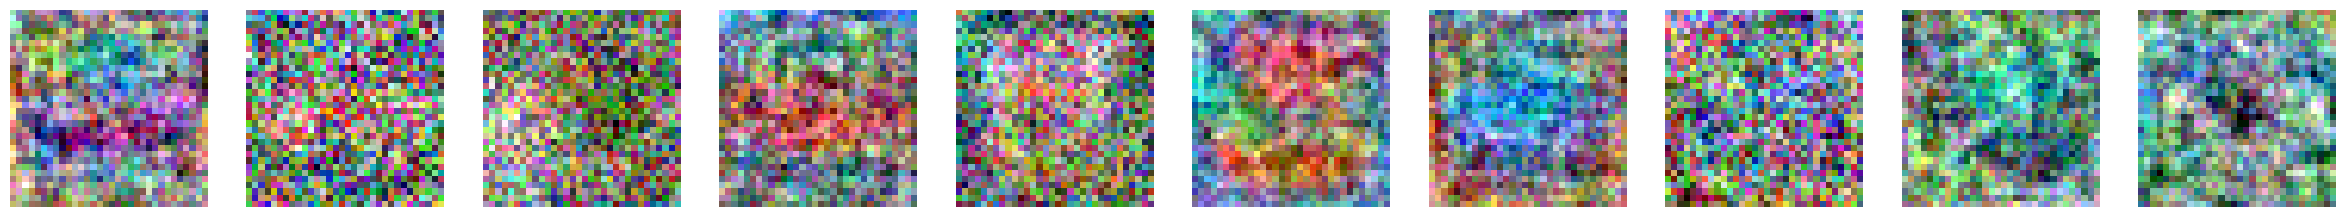

In [ ]:
weights = list(model.parameters())[0].detach().numpy()
print(f"Форма весов: {weights.shape}")

n_neurons = weights.shape[0]
fig, axes = plt.subplots(1, n_neurons, figsize=(3 * n_neurons, 3))

for i, w in enumerate(weights):
    w = w.reshape(32, 32, 3)
    w = w - np.percentile(w, 1)
    w = w / np.percentile(w, 99)
    w = np.clip(w, 0, 1)
    axes[i].imshow(w)
    axes[i].axis('off')

# Описание методов библиотек

### Методы и функции NumPy:

(Подробнее в документации https://numpy.org/doc/stable/reference/index.html)

* **`np.array`** — создание массива из списка или другого массива.

* **`np.shape`** — выводит размерность многомерного массива (например, для массива 2×2 будет кортеж `(2, 2)`).

* **`np.size`** — выводит общее число элементов в массиве (для массива 2×2 вернёт `4`).

* **`np.uint8`, `np.int16`, `np.int64`, `np.float32`** — приведение массива к новому типу (с выделением памяти под новый массив). Число обозначает битность: `uint8` — беззнаковый 8-битный целый (диапазон 0–255), часто используется для хранения изображений.

* **`np.ones`, `np.zeros`** — создание массивов, заполненных единицами или нулями. Размерность задаётся кортежем: `np.ones((10,))` — вектор из 10 единиц; `np.zeros((32, 32, 3))` — массив 32×32×3 (изображение). Используется для проверки архитектуры модели (forward pass).

* **`np.arange`** — создание массива с арифметической прогрессией от первого аргумента (включительно) до второго (не включительно) с шагом, заданным третьим аргументом. Первый и третий аргументы можно опускать: `np.arange(3)` → `[0, 1, 2]`.

* **`np.repeat`** — дублирование элементов массива. Например, `np.repeat([0, 1], 2)` → `[0, 0, 1, 1]`.

* **`np.exp`** — поэлементная экспонента (потенциирование).

* **`np.random.normal`** — генерация массива случайных чисел из нормального распределения. Параметры: `mean` (среднее), `scale` (стандартное отклонение), `size` (количество элементов).

* **`np.random.randint`** — генерация массива случайных целых чисел. Диапазон задаётся аналогично `np.arange`. Пример: `np.random.randint(0, 2, size=(1000, 2))`.

* **`np.reshape`** — изменение формы массива без выделения новой памяти (меняется только способ обхода). Примеры:
  * `np.reshape([0, 1, 2, 3], (2, 2))` → массив 2×2
  * `arr.reshape(2, 2)` — альтернативный синтаксис
  * `X.reshape(-1, 3072)` — автоматический расчёт размера (часто используется для выпрямления изображений: `[100, 32, 32, 3]` → `[100, 3072]`)

* **`np.transpose`** — перестановка осей массива. Для изображений используются форматы:
  * **NHWC** — `(N, H, W, C)` — батч, высота, ширина, каналы (удобно для визуализации)
  * **NCHW** — `(N, C, H, W)` — батч, каналы, высота, ширина (родной для PyTorch)
  * Пример перевода NHWC → NCHW: `np.transpose(X, (0, 3, 1, 2))`

* **`np.isin`** — поэлементная проверка вхождения элементов массива в коллекцию. Пример: `np.isin([0, 2, 1], [2, 3])` → `[False, True, False]`.

* **Индексирование** — выбор элементов с помощью квадратных скобок `[]`:
  * `arr[0]` — первый элемент
  * `arr[[0, 1]]` — выбор по индексам
  * `arr[[True, False, True]]` — выбор по булевой маске
  * `arr[:, k]` — выбор столбца `k` в двумерном массиве
  * `arr[1:2, 0:1]` — срез (пример: из `[[0,1],[2,3],[4,5]]` вернёт `[[2]]`)

* **`np.unique`** — возвращает уникальные элементы (аналог `SELECT DISTINCT`). С флагом `return_inverse=True` возвращает массив индексов для восстановления исходных меток (Label Encoding).

* **`np.concatenate`** — объединение массивов вдоль указанной оси (`axis`). Применяется для склейки данных, изображений, аудиодорожек.

* **`np.max`, `np.min`** — возвращают максимальный/минимальный элемент вдоль оси. Без оси — скаляр. Альтернативный синтаксис: `arr.max()`.

* **`np.argmax`** — возвращает индекс максимального элемента вдоль оси. Используется для расчёта Accuracy (номер предсказанного класса). Альтернативный синтаксис: `arr.argmax(axis=-1)`.

### Методы и функции Pickle

(Документация: https://docs.python.org/3/library/pickle.html)

**Pickle** — модуль для сериализации (сохранения) и десериализации (загрузки) Python-объектов. Позволяет сохранять на диск любые структуры данных: списки, словари, NumPy-массивы, а также модели машинного обучения (не рекомендуется для долгосрочного хранения моделей из-за нестабильности формата между версиями Python).

* **`pickle.dump(obj, file)`** — сериализует объект `obj` и записывает его в файловый объект `file`. Файл должен быть открыт в режиме записи байтов (`'wb'`). Необязательный параметр `protocol` позволяет выбрать версию протокола (чем выше, тем компактнее и быстрее, но требуется Python 3+). Пример:
  ```python
  with open('data.pkl', 'wb') as f:
      pickle.dump(data, f)
  ```

* **`pickle.load(file)`** — десериализует объект из файлового объекта `file`. Файл должен быть открыт в режиме чтения байтов (`'rb'`). Важно: при загрузке данных, сохранённых в Python 2, может потребоваться параметр `encoding='latin1'`. Пример:
  ```python
  with open('data.pkl', 'rb') as f:
      data = pickle.load(f, encoding='latin1')  # для совместимости с Python 2
  ```

**Важно:**
- Pickle **небезопасен** — не загружайте данные из непроверенных источников.
- Для хранения моделей глубокого обучения рекомендуется использовать `torch.save(model.state_dict(), 'model.pth')`, а не pickle.
- В CIFAR-100 данные хранятся в формате pickle (Python 2), поэтому при загрузке используется `encoding='latin1'`.

### Методы и функции Sklearn

(Документация: https://scikit-learn.org/stable/modules/classes.html)

**`sklearn.datasets.make_circles`, `sklearn.datasets.make_moons`** — генерация синтетических данных для задач классификации.

* **`make_circles`** — создаёт выборку из двух классов, расположенных в виде двух концентрических окружностей (один класс внутри, другой снаружи).
* **`make_moons`** — создаёт выборку из двух классов, расположенных в виде двух полумесяцев (как две дуги, повёрнутые друг к другу).

Обе функции возвращают:
* `X` — двумерный массив `(n_samples, 2)` (два признака — координаты точек)
* `y` — одномерный массив меток классов `(n_samples,)` (0 или 1)

Пример:
```python
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.05)
```

---

**`sklearn.metrics.classification_report`** — текстовый отчёт с основными метриками классификации:

* **precision** — точность (доля правильно предсказанных положительных среди всех предсказанных положительных)
* **recall** — полнота (доля правильно предсказанных положительных среди всех истинных положительных)
* **f1-score** — среднее гармоническое precision и recall
* **accuracy** — доля правильных ответов (внизу отчёта)

Параметры:
* `y_true` — истинные метки классов
* `y_pred` — предсказанные метки (индексы классов)
* `digits` — число знаков после запятой (по умолчанию 2)
* `target_names` — список названий классов (для читаемости)
* `output_dict=True` — возвращает словарь вместо строки (удобно для программной обработки)
* `sample_weight` — веса для каждого примера (взвешенные метрики)

Пример:
```python
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, digits=4, target_names=['class0', 'class1']))
```

---

**`sklearn.metrics.confusion_matrix`** — матрица ошибок (confusion matrix):

* Строки — истинные классы
* Столбцы — предсказанные классы
* Идеальная модель имеет значения только на главной диагонали

На основе матрицы ошибок можно вычислить все классические метрики:
* **Accuracy** — сумма диагонали / общее число
* **Precision** — TP / (TP + FP) для каждого класса
* **Recall** — TP / (TP + FN) для каждого класса
* **Specificity** — TN / (TN + FP)
* **F1-score** — 2 * (precision * recall) / (precision + recall)

Пример:
```python
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)
```

**Важно:** для многоклассовой классификации матрица имеет размер `(C, C)`, где `C` — число классов.

### Методы и функции PIL

(Документация: https://pillow.readthedocs.io/en/stable/)

**`Image.fromarray(arr)`** — создаёт объект `Image` из многомерного массива. Важные нюансы:
* **Тип данных:** ожидает `uint8`. Если передан `float32` или другой тип, изображение может отображаться некорректно.
* **Форма массива:** должна быть `(H, W)` — ч/б, `(H, W, 3)` — RGB, `(H, W, 4)` — RGBA. Для одноканального изображения форма `(H, W, 1)` вызовет ошибку — используйте `np.squeeze()`.
* Для обратного преобразования используйте `np.array(img)`.

**`Image.resize(size, resample=Image.BICUBIC)`** — изменяет разрешение изображения с интерполяцией.
* `size` — кортеж `(ширина, высота)`.
* `resample` — метод интерполяции (по умолчанию `BICUBIC`). Доступны: `NEAREST` (ближайший сосед), `BILINEAR`, `BICUBIC`, `LANCZOS` (самый качественный, но медленный). Пример: `img.resize((256, 256), resample=Image.LANCZOS)`.

**`Image.convert(mode)`** — переводит изображение в другую цветовую модель.
* `'L'` — градации серого (ч/б)
* `'RGB'` — цветное (3 канала)
* `'RGBA'` — цветное с прозрачностью
* `'HSV'` — цветовое пространство Hue, Saturation, Value
* `'CMYK'` — для печати

**`Image.open(fp)`** — открывает изображение из файла. Важно: `PIL` может неверно определить цветовой режим (например, открыть RGB-изображение как `'L'`). Рекомендуется сразу приводить к нужному формату: `Image.open(path).convert('RGB')`.

**`Image.save(fp, format=None)`** — сохраняет изображение.
* `fp` — путь к файлу или файловый объект.
* Если `fp` — файловый объект, нужно явно указать `format` (например, `'PNG'`, `'JPEG'`).

Пример использования в лабораторной работе:
```python
from PIL import Image

# Открытие и конвертация
img = Image.open('image.jpg').convert('RGB')

# Изменение размера
img_resized = img.resize((256, 256), resample=Image.LANCZOS)

# Преобразование в массив и обратно
arr = np.array(img_resized)
img_from_arr = Image.fromarray(arr.astype(np.uint8))

# Сохранение
img_from_arr.save('output.png')
```

### Методы и функции Matplotlib

(Документация: https://matplotlib.org/stable/api/index.html)

**Принятые сокращения:**
* `matplotlib.pyplot` — `plt`

---

**Основные методы:**

* **`plt.plot(x, y, ...)`** — строит линейный график по точкам, соединяя их линиями.
  * Если передать только один аргумент (`plt.plot(y)`), он будет использован как `y`, а `x` станет последовательностью `0, 1, 2, ...`.
  * **Полезные параметры:** `linestyle` (`'-'`, `'--'`, `':'`, `'-.'`), `color` (`'k'` — чёрный, `'r'` — красный, `'b'` — синий, `'g'` — зелёный, `'white'` — белый, `'#FF5733'` — hex-код), `alpha` (прозрачность от 0 до 1), `label` (метка для легенды).

* **`plt.scatter(x, y, ...)`** — строит диаграмму рассеяния (точки без соединения линиями).
  * **Полезные параметры:** `s` (размер точек), `c` (цвет), `alpha` (прозрачность), `label` (метка для легенды), `marker` (форма маркера: `'o'` — круг, `'s'` — квадрат, `'^'` — треугольник, `'D'` — ромб, `'v'` — треугольник вниз).

* **`plt.contourf(x, y, Z, ...)`** — рисует **заполненные** контурные линии (поверхность). Часто используется для визуализации разделяющих поверхностей классификаторов.
  * **Полезные параметры:** `cmap` (цветовая карта, например `'RdBu'`), `levels` (количество уровней или список границ), `alpha` (прозрачность).

* **`plt.show()`** — принудительно отображает все построенные графики. В Jupyter/Colab часто не требуется, но полезно для вывода нескольких графиков в одном блоке кода.

* **`plt.legend()`** — отображает легенду, используя метки (`label`), переданные в `plot`, `scatter` и другие функции.

* **`plt.xlim(left, right)`** — устанавливает границы отображения по горизонтальной оси (X). По умолчанию подбираются автоматически.
* **`plt.ylim(bottom, top)`** — аналогично, но для вертикальной оси (Y).

* **`plt.grid(True)`** — добавляет сетку на график (полезно для улучшения читаемости).

* **`plt.title('Текст')`** — добавляет заголовок графика.
* **`plt.xlabel('Текст')`**, **`plt.ylabel('Текст')`** — подписи осей X и Y.

---

**Интерфейсы Matplotlib:**
1. **Функциональный (pyplot)** — команды из `plt`. Удобен для быстрых и простых графиков (используется в лабораторной).
2. **Объектно-ориентированный (Axes)** — явное создание фигур и осей. Даёт больше контроля для сложных и вложенных графиков.

**Пример** (как в лабораторной):
```python
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', marker='o', alpha=0.7)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Визуализация данных')
plt.grid(True)
plt.colorbar(label='Класс')
plt.show()
```